# Task 04 : Saad Khan .. Decode lab

### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import isspmatrix_csr

### Download required NLTK corpora and taggers

In [2]:
nltk.download('movie_reviews')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

from nltk.corpus import movie_reviews, stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\Saad\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Saad\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Saad\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Saad\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Saad\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


### Extract movie_reviews corpus into DataFrame

In [3]:
documents = [
    (" ".join(movie_reviews.words(fileid)), movie_reviews.categories(fileid)[0])
    for category in movie_reviews.categories()
    for fileid in movie_reviews.fileids(category)
]

df = pd.DataFrame(documents, columns=['review', 'sentiment'])
df['target'] = df['sentiment'].map({'pos': 1, 'neg': 0})

print("Dataset Loaded Successfully:")
print(f"Total Rows: {len(df)} | Class Distribution:\n{df['sentiment'].value_counts()}")

Dataset Loaded Successfully:
Total Rows: 2000 | Class Distribution:
sentiment
neg    1000
pos    1000
Name: count, dtype: int64


### Custom Stop-Word List: Exclude Negation

In [4]:
default_stopwords = set(stopwords.words('english'))
negations = {
    'no', 'not', 'nor', 'neither', 'never', 'none', 'cannot',
    "isn't", "aren't", "wasn't", "weren't", "haven't", "hasn't",
    "hadn't", "won't", "wouldn't", "don't", "doesn't", "didn't",
    "can't", "couldn't", "shouldn't", "mightn't", "mustn't"
}
custom_stopwords = default_stopwords - negations

### Map Penn Treebank POS tags to WordNet POS tags

In [5]:
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

lemmatizer = WordNetLemmatizer()

### Full Text Cleaning and Token Processing Function

In [6]:
def preprocess_text(text):
    # Ensure the required NLTK tagger is available right before use
    nltk.download('averaged_perceptron_tagger_eng', quiet=True)

    # Remove HTML tags and non-alphabetic characters
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text).lower()

    tokens = text.split()
    tagged_tokens = nltk.pos_tag(tokens)

    # POS-Guided Lemmatization excluding negations
    cleaned_tokens = [
        lemmatizer.lemmatize(word, get_wordnet_pos(tag))
        for word, tag in tagged_tokens
        if word not in custom_stopwords
    ]
    return ' '.join(cleaned_tokens)

# Apply preprocessing pipeline to all reviews
print("Executing NLP Preprocessing Pipeline...")
df['cleaned_review'] = df['review'].apply(preprocess_text)
print("Sample Cleaned Output:\n", df[['review', 'cleaned_review']].head(1).values[0])

Executing NLP Preprocessing Pipeline...
Sample Cleaned Output:
 ['plot : two teen couples go to a church party , drink and then drive . they get into an accident . one of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . what \' s the deal ? watch the movie and " sorta " find out . . . critique : a mind - fuck movie for the teen generation that touches on a very cool idea , but presents it in a very bad package . which is what makes this review an even harder one to write , since i generally applaud films which attempt to break the mold , mess with your head and such ( lost highway & memento ) , but there are good and bad ways of making all types of films , and these folks just didn \' t snag this one correctly . they seem to have taken this pretty neat concept , but executed it terribly . so what are the problems with the movie ? well , its main problem is that it \' s simply too jumbled . it starts off " normal " but then downshifts into this 

In [7]:
# Initialize TF-IDF Vectorizer with engineering bounds
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),  # Capture single words and word pairs (e.g., "not good")
    max_features=10000,  # Bound maximum vocabulary dimension
    min_df=2             # Drop rare typos/outliers appearing in < 2 docs
)

# Transform unstructured text to sparse CSR matrix
X = tfidf.fit_transform(df['cleaned_review'])
y = df['target'].values

print(f"TF-IDF Matrix Shape: {X.shape}")
print(f"Stored in SciPy CSR Format: {isspmatrix_csr(X)}")

TF-IDF Matrix Shape: (2000, 10000)
Stored in SciPy CSR Format: True


### Train/Test

In [8]:
# Stratified 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Train Multinomial Naive Bayes Classifier with Laplace Smoothing
nb_classifier = MultinomialNB(alpha=1.0)
nb_classifier.fit(X_train, y_train)

print(f"Model Training Complete. Trained on {X_train.shape[0]} samples.")

Model Training Complete. Trained on 1600 samples.


### Prediction & Performance

In [9]:
# Generate predictions on test set
y_pred = nb_classifier.predict(X_test)

# Calculate performance metrics
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Test Accuracy: {accuracy * 100:.2f}%\n")
print("Detailed Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Negative (0)', 'Positive (1)']))

Model Test Accuracy: 81.50%

Detailed Classification Report:

              precision    recall  f1-score   support

Negative (0)       0.80      0.83      0.82       200
Positive (1)       0.83      0.80      0.81       200

    accuracy                           0.81       400
   macro avg       0.82      0.81      0.81       400
weighted avg       0.82      0.81      0.81       400



### Plot Confusion Matrix

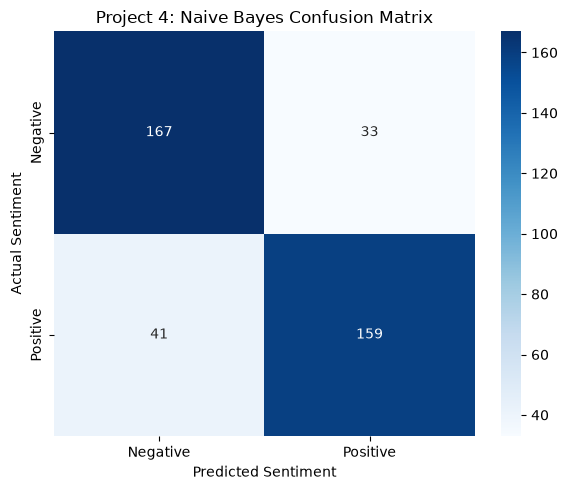

In [10]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Project 4: Naive Bayes Confusion Matrix')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.tight_layout()
plt.show()

In [11]:
def predict_sentiment(raw_text):
    # Process text through the exact same NLP pipeline
    cleaned = preprocess_text(raw_text)
    vectorized = tfidf.transform([cleaned])

    prediction = nb_classifier.predict(vectorized)[0]
    probabilities = nb_classifier.predict_proba(vectorized)[0]

    label = "POSITIVE" if prediction == 1 else "NEGATIVE"
    confidence = probabilities[prediction] * 100

    return label, confidence, cleaned

### Verification Test Cases (Testing Negation Handling)

In [12]:
test_sentences = [
    "The acting was brilliant, storyline was astonishing and well written!",
    "This product is terrible and broke within two days of use.",
    "The movie was not good at all, extremely boring and slow.",
    "I was not disappointed with the performance, it exceeded my expectations!"
]

print("--- Real-World Sentiment Inference Pipeline ---")
for text in test_sentences:
    label, conf, cleaned = predict_sentiment(text)
    print(f"\nRaw Input: '{text}'")
    print(f"Cleaned Tokens: '{cleaned}'")
    print(f"Prediction: [{label}] (Confidence: {conf:.2f}%)")

--- Real-World Sentiment Inference Pipeline ---

Raw Input: 'The acting was brilliant, storyline was astonishing and well written!'
Cleaned Tokens: 'acting brilliant storyline astonish well write'
Prediction: [POSITIVE] (Confidence: 59.24%)

Raw Input: 'This product is terrible and broke within two days of use.'
Cleaned Tokens: 'product terrible break within two day use'
Prediction: [NEGATIVE] (Confidence: 65.42%)

Raw Input: 'The movie was not good at all, extremely boring and slow.'
Cleaned Tokens: 'movie not good extremely boring slow'
Prediction: [NEGATIVE] (Confidence: 63.26%)

Raw Input: 'I was not disappointed with the performance, it exceeded my expectations!'
Cleaned Tokens: 'not disappointed performance exceed expectation'
Prediction: [POSITIVE] (Confidence: 58.33%)


### Gradio UI Integration

In [ ]:
import gradio as gr

# Define the Gradio interface
interface = gr.Interface(
    fn=predict_sentiment, # Your existing prediction function
    inputs=gr.Textbox(lines=5, label='Enter Review Text Here'),
    outputs=[
        gr.Label(label='Predicted Sentiment'),
        gr.Number(label='Confidence (%)'),
        gr.Textbox(label='Cleaned Tokens')
    ],
    title='Movie Review Sentiment Analyzer',
    description='Enter a movie review to get its predicted sentiment (Positive/Negative) and the model confidence.',
    live=False # Set to True for real-time predictions as you type
)

# Launch the interface
interface.launch(debug=True, share=True)

c:\Users\Saad\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://6fc501c69b9ddb652f.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
